In [1]:
!python -V

Python 3.9.12


In [2]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [16]:
import mlflow 

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1784583723573, experiment_id='1', last_update_time=1784583723573, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [4]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df['duration_t'] = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration_t >= 0) & (df.duration_t <= 60)]
    
    df = df[df.trip_type.notna()]
    
    df['lpep_pickup_hour']=df['lpep_pickup_datetime'].dt.hour
    
    df['lpep_pickup_dayofweek']=df['lpep_pickup_datetime'].dt.dayofweek
    
    df['lpep_pickup_weekend']=df['lpep_pickup_dayofweek'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')
    
    df['lpep_pickup_weekend_hour'] = df['lpep_pickup_weekend'].astype(str) + '_' + df['lpep_pickup_hour'].astype(str)
    
    df['PU_DO_LocationID'] = df['PULocationID'].astype(str) + '_' + df['DOLocationID'].astype(str)

    categorical = ['lpep_pickup_hour','PU_DO_LocationID']
    df[categorical] = df[categorical].astype(str)
    
    df['congestion_surcharge'].fillna(0, inplace=True)
    df['improvement_surcharge'].fillna(0, inplace=True)
    
    return df

In [5]:
df_train = read_dataframe('data/green_tripdata_2024-01.parquet')
df_val = read_dataframe('data/green_tripdata_2024-02.parquet')

In [6]:
len(df_train), len(df_val)

(52656, 50124)

In [7]:
df_train.duration_t.describe()

count    52656.000000
mean        12.976168
std          8.773712
min          0.000000
25%          7.100000
50%         11.100000
75%         16.550000
max         59.983333
Name: duration_t, dtype: float64

In [8]:
df_train.tail()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,payment_type,trip_type,congestion_surcharge,duration,duration_t,lpep_pickup_hour,lpep_pickup_dayofweek,lpep_pickup_weekend,lpep_pickup_weekend_hour,PU_DO_LocationID
53131,2,2024-01-31 23:48:18,2024-02-01 00:01:52,N,1.0,130,218,2.0,3.28,16.3,...,1.0,1.0,0.0,0 days 00:13:34,13.566667,23,2,weekday,weekday_23,130_218
53132,2,2024-01-31 23:14:12,2024-01-31 23:25:41,N,1.0,130,219,1.0,4.20,19.8,...,1.0,1.0,0.0,0 days 00:11:29,11.483333,23,2,weekday,weekday_23,130_219
53133,2,2024-01-31 23:19:14,2024-01-31 23:19:27,N,5.0,181,181,2.0,0.00,74.0,...,1.0,2.0,0.0,0 days 00:00:13,0.216667,23,2,weekday,weekday_23,181_181
53134,2,2024-01-31 23:22:53,2024-01-31 23:31:25,N,1.0,74,116,1.0,2.20,12.1,...,1.0,1.0,0.0,0 days 00:08:32,8.533333,23,2,weekday,weekday_23,74_116
53135,2,2024-01-31 23:22:45,2024-01-31 23:24:51,N,5.0,41,41,1.0,0.42,10.0,...,2.0,2.0,0.0,0 days 00:02:06,2.100000,23,2,weekday,weekday_23,41_41


In [9]:
df_train.lpep_pickup_weekend_hour.value_counts()

weekday_17    3513
weekday_18    3382
weekday_16    3286
weekday_15    3019
weekday_19    2634
weekday_14    2549
weekday_9     2296
weekday_13    2284
weekday_10    2202
weekday_8     2192
weekday_11    2180
weekday_12    2159
weekday_20    1932
weekday_7     1906
weekday_21    1400
weekday_22    1142
weekday_23     861
weekend_15     836
weekend_17     824
weekend_18     818
weekend_16     808
weekend_14     772
weekend_19     758
weekday_6      698
weekend_13     696
weekend_12     593
weekend_11     580
weekday_0      577
weekend_20     568
weekend_21     481
weekend_10     476
weekend_0      393
weekend_9      391
weekend_22     383
weekday_1      369
weekend_23     352
weekend_1      348
weekend_2      272
weekend_8      254
weekday_2      231
weekend_3      226
weekday_5      214
weekend_7      187
weekday_3      156
weekend_4      141
weekday_4      140
weekend_6      109
weekend_5       68
Name: lpep_pickup_weekend_hour, dtype: int64

In [6]:
categorical = ['PU_DO_LocationID',
               'lpep_pickup_weekend_hour', 'trip_type', 'congestion_surcharge', 'improvement_surcharge']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

with open('models/preprocessor.b', 'wb') as f_out:
    pickle.dump((dv), f_out)
    
target = 'duration_t'
y_train = df_train[target].values
y_val = df_val[target].values

In [17]:
with mlflow.start_run():

    mlflow.set_tag("developer", "sameh")
    mlflow.log_param("train-data-path", "data/green_tripdata_2024-01.parquet")
    mlflow.log_param("val-data-path", "data/green_tripdata_2024-02.parquet")
    mlflow.log_param("model_type", "linear_regression")


    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse=np.sqrt(mean_squared_error(y_val, y_pred))
    rmse
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path='models/preprocessor.b', artifact_path='preprocessor')
    #with open('models/lin_reg.bin', 'wb') as f_out:
        #pickle.dump((lr), f_out)
    #mlflow.log_artifact(local_path='models/lin_reg.bin', artifact_path='models_pickle')
    mlflow.sklearn.log_model(lr, artifact_path="models_mlflow")

2026/07/22 00:03:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/22 00:03:50 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpgfw7po8_/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/22 00:03:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [18]:
with mlflow.start_run():

    mlflow.set_tag("developer", "sameh")
    mlflow.log_param("train-data-path", "data/green_tripdata_2024-01.parquet")
    mlflow.log_param("val-data-path", "data/green_tripdata_2024-02.parquet")
    mlflow.log_param("model_type", "ridge_regression")


    alpha=0.00001
    mlflow.log_param("alpha", 0.00001)

    lr = Ridge(alpha=alpha)

    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse=np.sqrt(mean_squared_error(y_val, y_pred))
    rmse
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path='models/preprocessor.b', artifact_path='preprocessor')
    #with open('models/ridge_reg.bin', 'wb') as f_out:
        #pickle.dump((lr), f_out)
    #mlflow.log_artifact(local_path='models/ridge_reg.bin', artifact_path='models_pickle')
    mlflow.sklearn.log_model(lr, artifact_path="models_mlflow")

2026/07/22 00:03:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/22 00:03:52 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp9ag2rf5s/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/22 00:03:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


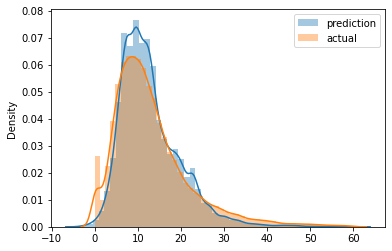

In [13]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_val, label='actual')

plt.legend()

In [14]:
import xgboost as xgb

In [15]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [16]:
categorical = [#'PU_DO_LocationID',
               'lpep_pickup_weekend_hour', 'trip_type', 'congestion_surcharge', 'improvement_surcharge', 'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

with open('models/preprocessor_v2.b', 'wb') as f_out:
    pickle.dump((dv), f_out)
    
target = 'duration_t'
y_train = df_train[target].values
y_val = df_val[target].values

In [17]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [19]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("developer", "sameh")
        mlflow.log_param("train-data-path", "data/green_tripdata_2024-01.parquet")
        mlflow.log_param("val-data-path", "data/green_tripdata_2024-02.parquet")
        mlflow.log_param("model_type", "xgboost")
        mlflow.log_params(params)
        mlflow.log_artifact(local_path='models/preprocessor_v2.b', artifact_path='preprocessor')
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=100,
            evals=[(valid, 'validation')],
            early_stopping_rounds=5
        )
        y_pred = booster.predict(valid)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [20]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 25, 1)),
    'learning_rate': hp.loguniform('learning_rate', -4, -2),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -2, 2),
    #'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=5,
    trials=Trials()
)

[0]	validation-rmse:8.64748                                                          
[1]	validation-rmse:8.36680                                                          
[2]	validation-rmse:8.10546                                                          
[3]	validation-rmse:7.86215                                                          
[4]	validation-rmse:7.63451                                                          
[5]	validation-rmse:7.42142                                                          
[6]	validation-rmse:7.22355                                                          
[7]	validation-rmse:7.03946                                                          
[8]	validation-rmse:6.86801                                                          
[9]	validation-rmse:6.70777                                                          
[10]	validation-rmse:6.55586                                                         
[11]	validation-rmse:6.41673                          

[90]	validation-rmse:5.02536                                                         
[91]	validation-rmse:5.02204                                                         
[92]	validation-rmse:5.01934                                                         
[93]	validation-rmse:5.01562                                                         
[94]	validation-rmse:5.00841                                                         
[95]	validation-rmse:5.00538                                                         
[96]	validation-rmse:5.00232                                                         
[97]	validation-rmse:4.99925                                                         
[98]	validation-rmse:4.99620                                                         
[99]	validation-rmse:4.99216                                                         
[0]	validation-rmse:8.40431                                                          
[1]	validation-rmse:7.92699                           

[85]	validation-rmse:5.05869                                                         
[86]	validation-rmse:5.05776                                                         
[87]	validation-rmse:5.05743                                                         
[88]	validation-rmse:5.05745                                                         
[89]	validation-rmse:5.05710                                                         
[90]	validation-rmse:5.05676                                                         
[91]	validation-rmse:5.05645                                                         
[92]	validation-rmse:5.05711                                                         
[93]	validation-rmse:5.05644                                                         
[94]	validation-rmse:5.05588                                                         
[95]	validation-rmse:5.05591                                                         
[96]	validation-rmse:5.05542                          

In [21]:
with mlflow.start_run():

    mlflow.set_tag("developer", "sameh")
    mlflow.log_param("train-data-path", "data/green_tripdata_2024-01.parquet")
    mlflow.log_param("val-data-path", "data/green_tripdata_2024-02.parquet")
    mlflow.log_param("model_type", "xgboost")


    best_params={
        "learning_rate": 0.08944777868968097,
        "max_depth": 15,
        "min_child_weight": 3.9466315707096298,
        #"objective": "reg:linear",
        "reg_alpha": 0.1359070464297258,
        "reg_lambda": 0.0031192521420431406,
        "seed": 42
    }
    
    mlflow.xgboost.autolog()
    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=100,
        evals=[(valid, 'validation')],
        early_stopping_rounds=5
    )
    y_pred = booster.predict(valid)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mlflow.log_metric("rmse", rmse)
    

    mlflow.log_artifact(local_path='models/preprocessor_v2.b', artifact_path='preprocessor')
    
    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

[0]	validation-rmse:8.40431
[1]	validation-rmse:7.92699
[2]	validation-rmse:7.50950
[3]	validation-rmse:7.14260
[4]	validation-rmse:6.82050
[5]	validation-rmse:6.54536
[6]	validation-rmse:6.29930
[7]	validation-rmse:6.08549
[8]	validation-rmse:5.90704
[9]	validation-rmse:5.74680
[10]	validation-rmse:5.61302
[11]	validation-rmse:5.50027
[12]	validation-rmse:5.39774
[13]	validation-rmse:5.31390
[14]	validation-rmse:5.23984
[15]	validation-rmse:5.17869
[16]	validation-rmse:5.12690
[17]	validation-rmse:5.08622
[18]	validation-rmse:5.04902
[19]	validation-rmse:5.01583
[20]	validation-rmse:4.98670
[21]	validation-rmse:4.96380
[22]	validation-rmse:4.94382
[23]	validation-rmse:4.92509
[24]	validation-rmse:4.90675
[25]	validation-rmse:4.89307
[26]	validation-rmse:4.88190
[27]	validation-rmse:4.87029
[28]	validation-rmse:4.85731
[29]	validation-rmse:4.84657
[30]	validation-rmse:4.83874
[31]	validation-rmse:4.82777
[32]	validation-rmse:4.82293
[33]	validation-rmse:4.81758
[34]	validation-rmse:4.8

2026/07/21 14:39:11 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/07/21 14:39:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 14:39:12 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:39:12] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/07/21 14:39:15 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp9nu2l2ww/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/07/21 14:39:15 WARNING mlflow.models.mod

In [22]:
logged_model = '/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1/models/m-d4636a131e404d24b852e88f434236fe/artifacts'
loaded_model = mlflow.pyfunc.load_model(logged_model)

In [23]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: /workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1/models/m-d4636a131e404d24b852e88f434236fe/artifacts
  flavor: mlflow.xgboost
  run_id: cc53943f85f449faa013363526f7d473

In [24]:
xgboost_model = mlflow.xgboost.load_model(logged_model)
xgboost_model

In [25]:
logged_preprocessor = '/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1/cc53943f85f449faa013363526f7d473/artifacts/preprocessor/preprocessor_v2.b'
loaded_preprocessor = mlflow.artifacts.download_artifacts(logged_preprocessor)
loaded_preprocessor

'/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1/cc53943f85f449faa013363526f7d473/artifacts/preprocessor/preprocessor_v2.b'

In [26]:
with open(loaded_preprocessor, "rb") as f:
    preprocessor = pickle.load(f)

In [27]:
preprocessor

DictVectorizer()

In [28]:
X_val_bis = preprocessor.transform(val_dicts)

In [29]:
valid_bis = xgb.DMatrix(X_val_bis, label=y_val)

In [30]:
y_pred_bis=xgboost_model.predict(valid_bis)
y_pred_bis

array([13.247957 , 20.086004 ,  4.5426993, ..., 10.919368 , 13.340874 ,
        6.5187864], dtype=float32)

In [31]:
y_pred

array([13.247957 , 20.086004 ,  4.5426993, ..., 10.919368 , 13.340874 ,
        6.5187864], dtype=float32)

In [15]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import LinearSVR

mlflow.sklearn.autolog()

for model_class in (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, LinearSVR):

    with mlflow.start_run():

        mlflow.set_tag("developer", "sameh")
        mlflow.log_param("train-data-path", "data/green_tripdata_2024-01.parquet")
        mlflow.log_param("val-data-path", "data/green_tripdata_2024-02.parquet")
        
        mlflow.log_artifact("models/preprocessor_v2.b", artifact_path="preprocessor")

        mlmodel = model_class()
        mlflow.log_param("model_type", model_class.__name__)
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mlflow.log_metric("rmse", rmse)
        print("done")

2026/07/21 14:24:04 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp4k9o8_o6/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/21 14:24:21 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpieilgb1b/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/21 14:29:49 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpd_ujnm5e/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
/home/codespace/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: Conv

In [19]:
from mlflow.tracking import MlflowClient
import pickle

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"

In [20]:
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [21]:
df = read_dataframe("data/green_tripdata_2024-03.parquet")

In [23]:
def test_model(name, stage, X_test, y_test):
    model = mlflow.pyfunc.load_model(f"models:/{name}/{stage}")
    y_pred = model.predict(X_test)
    return {"rmse": np.sqrt(mean_squared_error(y_test, y_pred))}

In [34]:
logged_preprocessor = '/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1/772ab40f736e4d65ad148ca6e7b93c42/artifacts/preprocessor/preprocessor.b'
loaded_preprocessor = mlflow.artifacts.download_artifacts(logged_preprocessor)
with open(loaded_preprocessor, "rb") as f:
    dv = pickle.load(f)
    
#client.download_artifacts(run_id="772ab40f736e4d65ad148ca6e7b93c42", path='preprocessor', dst_path='.')
#with open("preprocessor/preprocessor.b", "rb") as f_in:
#    dv = pickle.load(f_in)
    
categorical = ['PU_DO_LocationID', 'lpep_pickup_weekend_hour', 'trip_type', 'congestion_surcharge', 'improvement_surcharge']
numerical = ['trip_distance']
X_test = dv.transform(df[categorical + numerical].to_dict(orient='records'))

target = "duration_t"
y_test = df[target].values

%time test_model(name="nyc-taxi-regressor", stage="Staging", X_test=X_test, y_test=y_test)

CPU times: user 25.7 ms, sys: 982 µs, total: 26.7 ms
Wall time: 26.7 ms


{'rmse': 5.817901799892043}

In [ ]:
client.download_artifacts(run_id="058f4f337ce546178c17ca6e6a4671f8", path='preprocessor', dst_path='.')
with open("preprocessor/preprocessor_v2.b", "rb") as f_in:
    dv = pickle.load(f_in)
    
categorical = [#'PU_DO_LocationID',
               'lpep_pickup_weekend_hour', 'trip_type', 'congestion_surcharge', 'improvement_surcharge', 'PULocationID', 'DOLocationID']
numerical = ['trip_distance']
X_test = dv.transform(df[categorical + numerical].to_dict(orient='records'))

target = "duration_t"
y_test = df[target].values

%time test_model(name="nyc-taxi-regressor", stage="Staging", X_test=X_test, y_test=y_test)

In [29]:
client.download_artifacts(run_id="058f4f337ce546178c17ca6e6a4671f8", path='preprocessor', dst_path='.')
with open("preprocessor/preprocessor_v2.b", "rb") as f_in:
    dv = pickle.load(f_in)

categorical = [#'PU_DO_LocationID',
               'lpep_pickup_weekend_hour', 'trip_type', 'congestion_surcharge', 'improvement_surcharge', 'PULocationID', 'DOLocationID']
numerical = ['trip_distance']
X_test = dv.transform(df[categorical + numerical].to_dict(orient='records'))

target = "duration_t"
y_test = df[target].values

%time test_model(name="nyc-taxi-regressor", stage="Production", X_test=X_test, y_test=y_test)

CPU times: user 1.18 s, sys: 23.2 ms, total: 1.2 s
Wall time: 728 ms


{'rmse': 4.909964613645406}

In [14]:
client.transition_model_version_stage(
    name="nyc-taxi-regressor",
    version=1,
    stage="Production",
    archive_existing_versions=True
)

/tmp/ipykernel_39365/2705691151.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1784644964222, current_stage='Production', deployment_job_state=None, description='', last_updated_timestamp=1784646727332, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='', run_link='', source='/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1/models/m-d4636a131e404d24b852e88f434236fe/artifacts', status='READY', status_message=None, tags={'model type': 'xgboost', 'name': 'calm-sow-78'}, user_id=None, version=1>